# Notebook 10: DR Prediction Pipeline — Single Image & Batch Inference

## EfficientNet-B3 Diabetic Retinopathy Grading System

**Purpose:** End-to-end prediction pipeline for diabetic retinopathy detection and grading from retinal fundus images.

### How to Use
1. Run cells 1–6 (setup, config, preprocessing, model loading, functions)
2. **Edit Cell 7** — set `IMAGE_PATH` and `SINGLE_IMAGE`
3. **Run All** remaining cells — predictions + visualization are automatic

### Pipeline Overview
```
Raw Fundus Image ─→ Circle Crop ─→ Ben Graham ─→ CLAHE ─→ Resize(384) ─→ Normalize ─→ Model ─→ Result
     (BGR)          (bounding rect   (addWeighted     (LAB L-channel)  (INTER_AREA/   (ImageNet      │
                     + 2% margin)     4x − 4x + 128)                   INTER_CUBIC)   mean/std)      │
                                                                                              ┌──────┴──────┐
                                                                                          Binary         Multi-Class
                                                                                       (Sigmoid,1)     (Softmax,5)
                                                                                           │                │
                                                                                       DR / No DR      Grade 0–4
```

> **Important:** All preprocessing functions are copied **exactly** from `Notebook_01_Preprocessing_Pipeline.ipynb` to ensure train-inference consistency.

In [3]:
# ============================================================================
# 1. Imports
# ============================================================================
import os
import sys
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Union
from datetime import datetime

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
from torchvision import transforms

# Image Processing
import cv2
from PIL import Image

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("All imports loaded")
print(f"PyTorch {torch.__version__} | timm {timm.__version__}")
print(f"Device: {'CUDA (' + torch.cuda.get_device_name(0) + ')' if torch.cuda.is_available() else 'CPU'}")


All imports loaded
PyTorch 2.7.1 | timm 1.0.24
Device: CPU


In [4]:
# ============================================================================
# 2. Configuration
# ============================================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CONFIG = {
    # Model
    'model_name': 'efficientnet_b3',
    'image_size': 384,
    'dropout_rate': 0.4,

    # Paths
    'model_dir': Path('models'),
    'output_dir': Path('predics'),

    # Preprocessing (MUST match Notebook_01_Preprocessing_Pipeline.ipynb)
    'ben_graham_sigma': 30,
    'clahe_clip_limit': 2.0,
    'clahe_tile_grid': (8, 8),
    'pad_color': (0, 0, 0),     # Black padding (BGR)

    # ImageNet normalization (used during training)
    'mean': [0.485, 0.456, 0.406],
    'std':  [0.229, 0.224, 0.225],

    # Thresholds
    'binary_threshold': 0.5,
    'optimal_threshold': 0.4706,      # Youden's J from APTOS evaluation
}

# Clinical grade definitions
GRADE_INFO = {
    0: {'name': 'No DR',              'severity': 'Normal',   'color': '#2ecc71', 'action': 'Routine screening in 12 months'},
    1: {'name': 'Mild NPDR',          'severity': 'Low',      'color': '#f39c12', 'action': 'Re-examine in 6-12 months'},
    2: {'name': 'Moderate NPDR',      'severity': 'Moderate', 'color': '#e67e22', 'action': 'Re-examine in 3-6 months; consider referral'},
    3: {'name': 'Severe NPDR',        'severity': 'High',     'color': '#e74c3c', 'action': 'Urgent referral to ophthalmologist'},
    4: {'name': 'Proliferative DR',   'severity': 'Critical', 'color': '#8e44ad', 'action': 'Immediate referral; risk of vision loss'},
}

BINARY_INFO = {
    0: {'name': 'No DR (Healthy)',   'color': '#2ecc71'},
    1: {'name': 'DR (Diseased)',     'color': '#e74c3c'},
}

print("Configuration loaded")
print(f"  Model:       {CONFIG['model_name']}")
print(f"  Image size:  {CONFIG['image_size']}x{CONFIG['image_size']}")
print(f"  Ben Graham:  sigma={CONFIG['ben_graham_sigma']}")
print(f"  CLAHE:       clip={CONFIG['clahe_clip_limit']}, grid={CONFIG['clahe_tile_grid']}")
print(f"  Device:      {DEVICE}")


Configuration loaded
  Model:       efficientnet_b3
  Image size:  384x384
  Ben Graham:  sigma=30
  CLAHE:       clip=2.0, grid=(8, 8)
  Device:      cpu


## 2. Preprocessing Pipeline

> **These functions are copied exactly from `Notebook_01_Preprocessing_Pipeline.ipynb`** to ensure identical preprocessing between training and inference.

All functions operate on **BGR** images (OpenCV default format).

| Step | Function | Key Parameters | Notes |
|------|----------|---------------|-------|
| 1 | `circle_crop()` | `tol=10` | Bounding rect crop + 2% margin, morphological close |
| 2 | `ben_graham_preprocess()` | `sigma=30` | `addWeighted(img, 4, blur, -4, 128)` |
| 3 | `apply_clahe()` | `clip=2.0, grid=(8,8)` | LAB L-channel only |
| 4 | `resize_with_padding()` | `target=384` | INTER_AREA (down) / INTER_CUBIC (up) + copyMakeBorder |


In [6]:
# ============================================================================
# 3. Preprocessing Functions — EXACT from Notebook_01_Preprocessing_Pipeline
# ============================================================================
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  WARNING: Do NOT modify these functions. They must match training.     ║
# ║  Source: Notebook_01_Preprocessing_Pipeline.ipynb, Cell 3              ║
# ╚══════════════════════════════════════════════════════════════════════════╝

def circle_crop(img: np.ndarray, tol: int = 10) -> np.ndarray:
    """Detect the circular fundus region and crop away black borders.

    Uses thresholding on the green channel (most informative for fundus images)
    to find the largest bright region, then crops to its bounding circle.

    Args:
        img: BGR image (H, W, 3).
        tol: Pixel intensity threshold for foreground detection.

    Returns:
        Cropped BGR image containing only the fundus region.
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, mask = cv2.threshold(gray, tol, 255, cv2.THRESH_BINARY)

    # Morphological close to fill small holes
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Find contours and pick the largest one
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img  # Fallback: return original

    largest = max(contours, key=cv2.contourArea)

    # Get bounding rect of the largest contour
    x, y, w, h = cv2.boundingRect(largest)

    # Add small margin (2% of dimension) to avoid cutting the edge
    margin_x = int(w * 0.02)
    margin_y = int(h * 0.02)
    x = max(0, x - margin_x)
    y = max(0, y - margin_y)
    w = min(img.shape[1] - x, w + 2 * margin_x)
    h = min(img.shape[0] - y, h + 2 * margin_y)

    cropped = img[y:y+h, x:x+w]

    # Safety: don't return tiny/empty crops
    if cropped.shape[0] < 50 or cropped.shape[1] < 50:
        return img

    return cropped


def ben_graham_preprocess(img: np.ndarray, sigma: int = 30) -> np.ndarray:
    """Ben Graham's preprocessing: subtract local average colour.

    Formula: result = cv2.addWeighted(img, 4, GaussianBlur(img), -4, 128)

    Args:
        img: BGR image (any size).
        sigma: Gaussian blur sigma; larger = more global averaging.

    Returns:
        Illumination-normalised BGR image (same size).
    """
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    result = cv2.addWeighted(img, 4, blurred, -4, 128)
    return result


def apply_clahe(img: np.ndarray,
                clip_limit: float = 2.0,
                tile_grid_size: Tuple[int, int] = (8, 8)) -> np.ndarray:
    """Apply CLAHE to the L channel of LAB colour space.

    Args:
        img: BGR image.
        clip_limit: CLAHE contrast clip limit.
        tile_grid_size: Grid size for adaptive equalisation tiles.

    Returns:
        Contrast-enhanced BGR image.
    """
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_enhanced = clahe.apply(l_channel)

    lab_enhanced = cv2.merge([l_enhanced, a_channel, b_channel])
    result = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2BGR)
    return result


def resize_with_padding(img: np.ndarray,
                        target_size: int = 384,
                        pad_color: Tuple[int, int, int] = (0, 0, 0)) -> np.ndarray:
    """Resize image to target_size x target_size, preserving aspect ratio with padding.

    Args:
        img: BGR image.
        target_size: Desired square output dimension.
        pad_color: BGR colour for padding pixels.

    Returns:
        Square BGR image of shape (target_size, target_size, 3).
    """
    h, w = img.shape[:2]
    scale = target_size / max(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    # Use INTER_AREA for downscaling (anti-aliased), INTER_CUBIC for upscaling
    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    resized = cv2.resize(img, (new_w, new_h), interpolation=interp)

    # Compute padding
    pad_top = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left = (target_size - new_w) // 2
    pad_right = target_size - new_w - pad_left

    padded = cv2.copyMakeBorder(resized, pad_top, pad_bottom, pad_left, pad_right,
                                 cv2.BORDER_CONSTANT, value=pad_color)
    return padded


def preprocess_fundus_image(image_path: str,
                            config: dict = CONFIG,
                            return_steps: bool = False) -> Union[torch.Tensor, Tuple]:
    """
    Full preprocessing pipeline: raw image -> model-ready tensor.

    Pipeline: Circle Crop -> Ben Graham -> CLAHE -> Resize -> Normalize
    All operations in BGR space (OpenCV default), converted to RGB tensor at the end.

    Args:
        image_path: Path to the fundus image
        config: Configuration dictionary
        return_steps: If True, return intermediate BGR images for visualization

    Returns:
        If return_steps=False: tensor [C, H, W] normalized (RGB)
        If return_steps=True:  (tensor, dict of intermediate BGR images)
    """
    # Read image (OpenCV reads as BGR)
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    steps = {'01_original': img.copy()} if return_steps else None

    # Step 1: Circle crop (BGR in, BGR out)
    cropped = circle_crop(img, tol=10)
    if return_steps:
        steps['02_circle_crop'] = cropped.copy()

    # Step 2: Ben Graham (BGR in, BGR out)
    graham = ben_graham_preprocess(cropped, sigma=config['ben_graham_sigma'])
    if return_steps:
        steps['03_ben_graham'] = graham.copy()

    # Step 3: CLAHE (BGR in, BGR out)
    enhanced = apply_clahe(graham,
                           clip_limit=config['clahe_clip_limit'],
                           tile_grid_size=config['clahe_tile_grid'])
    if return_steps:
        steps['04_clahe'] = enhanced.copy()

    # Step 4: Resize with padding (BGR in, BGR out)
    final = resize_with_padding(enhanced,
                                target_size=config['image_size'],
                                pad_color=config['pad_color'])
    if return_steps:
        steps['05_resized'] = final.copy()

    # Step 5: BGR -> RGB -> tensor [C, H, W] -> normalize
    rgb = cv2.cvtColor(final, cv2.COLOR_BGR2RGB)
    normalize = transforms.Normalize(mean=config['mean'], std=config['std'])
    tensor = torch.from_numpy(rgb).permute(2, 0, 1).float() / 255.0
    tensor = normalize(tensor)

    if return_steps:
        return tensor, steps
    return tensor


print("Preprocessing pipeline defined (EXACT copy from Notebook_01)")
print(f"  Pipeline: Circle Crop (tol=10, bounding rect + 2% margin)")
print(f"         -> Ben Graham  (addWeighted, sigma={CONFIG['ben_graham_sigma']})")
print(f"         -> CLAHE       (clip={CONFIG['clahe_clip_limit']}, grid={CONFIG['clahe_tile_grid']})")
print(f"         -> Resize      ({CONFIG['image_size']}x{CONFIG['image_size']}, INTER_AREA/CUBIC)")
print(f"         -> Normalize   (ImageNet mean/std)")


Preprocessing pipeline defined (EXACT copy from Notebook_01)
  Pipeline: Circle Crop (tol=10, bounding rect + 2% margin)
         -> Ben Graham  (addWeighted, sigma=30)
         -> CLAHE       (clip=2.0, grid=(8, 8))
         -> Resize      (384x384, INTER_AREA/CUBIC)
         -> Normalize   (ImageNet mean/std)


## 3. Model Loading

In [8]:
# ============================================================================
# 4. Load Trained Models
# ============================================================================

def load_model(ckpt_path, model_name='efficientnet_b3', num_classes=1, dropout=0.4, device='cpu'):
    """Load a trained EfficientNet-B3 model from checkpoint."""
    model = timm.create_model(model_name, pretrained=False)
    n_features = model.classifier.in_features  # 1536
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(n_features, num_classes),
    )
    ckpt = torch.load(str(ckpt_path), map_location='cpu', weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model = model.to(device)
    model.eval()
    return model, ckpt


# ── Load Binary Model (1 sigmoid output) ──
binary_model, binary_ckpt = load_model(
    CONFIG['model_dir'] / 'best_binary_model.pth',
    num_classes=1, device=DEVICE
)
print(f"Binary model loaded  | val AUC: {binary_ckpt.get('best_val_auc', 0):.4f} | params: {sum(p.numel() for p in binary_model.parameters()):,}")

# ── Load Multi-Class Model (5 softmax outputs) ──
multiclass_model, multi_ckpt = load_model(
    CONFIG['model_dir'] / 'best_multiclass_model.pth',
    num_classes=5, device=DEVICE
)
print(f"Multi-class loaded   | val QWK: {multi_ckpt.get('best_val_qwk', 0):.4f} | params: {sum(p.numel() for p in multiclass_model.parameters()):,}")

# Verification
with torch.no_grad():
    dummy = torch.randn(1, 3, 384, 384).to(DEVICE)
    assert binary_model(dummy).shape == (1, 1), "Binary output shape wrong"
    assert multiclass_model(dummy).shape == (1, 5), "Multi-class output shape wrong"
print(f"\nModels verified: binary -> [B,1] sigmoid | multi -> [B,5] softmax")


Binary model loaded  | val AUC: 0.9958 | params: 10,697,769
Multi-class loaded   | val QWK: 0.8636 | params: 10,703,917

Models verified: binary -> [B,1] sigmoid | multi -> [B,5] softmax


## 4. Prediction Configuration

Set your image paths here, then **Run All** below to get predictions.


In [45]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  PREDICTION SETTINGS — Set these variables, then Run All below         ║
# ╚══════════════════════════════════════════════════════════════════════════╝

# Path to a single image OR a folder of images
IMAGE_PATH = 'predics/idrid_IDRiD_1196.jpg'
# IMAGE_PATH = 'predics/DR1.jpg'
# IMAGE_PATH = 'IDRiD/Test/images'          # folder for batch mode
# IMAGE_PATH = 'predics'                    # folder for batch mode

# True  = predict ONE image  (visual report + clinical summary)
# False = predict ALL images in folder (batch mode + CSV/JSON export)
SINGLE_IMAGE = True

# Test-Time Augmentation (TTA) — averages predictions over augmented views
# Matches Notebook_06 approach: HFlip, VFlip, Rotate90 combinations (8 views)
USE_TTA    = True     # True = enable 8x TTA,  False = single forward pass
TTA_TIMES  = 8        # Number of augmented views (1=original only, 8=full TTA)

# ── Validate ──
from pathlib import Path as _P
_path = _P(IMAGE_PATH)
if not _path.exists():
    raise FileNotFoundError(f"Path not found: {IMAGE_PATH}")
_mode = "SINGLE IMAGE" if SINGLE_IMAGE else f"BATCH ({len(list(_path.iterdir())) if _path.is_dir() else 1} images)"
_tta = f"TTA x{TTA_TIMES}" if USE_TTA else "No TTA"
print(f"Mode:  {_mode}")
print(f"TTA:   {_tta}")
print(f"Path:  {IMAGE_PATH}")
print(f"Ready — run the cells below to get predictions.")

Mode:  SINGLE IMAGE
TTA:   TTA x8
Path:  predics/idrid_IDRiD_1196.jpg
Ready — run the cells below to get predictions.


In [47]:
# ============================================================================
# 5. Single Image Prediction Core Function
# ============================================================================

def predict_single_image(image_path: str,
                         binary_model: nn.Module,
                         multiclass_model: nn.Module,
                         threshold: float = 0.5,
                         device: torch.device = DEVICE,
                         return_preprocessing: bool = False) -> Dict:
    """
    Full inference on a single retinal fundus image.

    Args:
        image_path:   Path to fundus image (jpg/png)
        binary_model: Loaded binary DR model (sigmoid output)
        multiclass_model: Loaded 5-class DR model (softmax output)
        threshold:    Binary classification threshold
        device:       torch device
        return_preprocessing: Whether to return preprocessing steps

    Returns:
        Dictionary with prediction results
    """
    start_time = time.time()

    # Preprocess (using exact Notebook_01 pipeline)
    if return_preprocessing:
        tensor, steps = preprocess_fundus_image(image_path, CONFIG, return_steps=True)
    else:
        tensor = preprocess_fundus_image(image_path, CONFIG, return_steps=False)
        steps = None

    # Add batch dimension: [1, C, H, W]
    batch = tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        # Binary prediction (sigmoid)
        binary_logit = binary_model(batch)                # [1, 1]
        binary_prob = torch.sigmoid(binary_logit).item()  # scalar
        binary_pred = int(binary_prob >= threshold)

        # Multi-class prediction (softmax)
        multi_logit = multiclass_model(batch)             # [1, 5]
        multi_probs = F.softmax(multi_logit, dim=1)[0]    # [5]
        multi_pred = multi_logit.argmax(dim=1).item()     # scalar
        multi_confidence = multi_probs[multi_pred].item()
        multi_probs_dict = {int(i): float(p) for i, p in enumerate(multi_probs.cpu().numpy())}

    elapsed = time.time() - start_time

    result = {
        'image_path': str(image_path),
        'image_name': Path(image_path).name,
        'timestamp': datetime.now().isoformat(),
        'inference_time_ms': round(elapsed * 1000, 1),

        # Binary
        'binary_probability': float(binary_prob),
        'binary_prediction': binary_pred,
        'binary_label': BINARY_INFO[binary_pred]['name'],
        'binary_confidence': float(max(binary_prob, 1 - binary_prob)),
        'threshold_used': threshold,

        # Multi-class
        'multiclass_prediction': int(multi_pred),
        'multiclass_grade': GRADE_INFO[multi_pred]['name'],
        'multiclass_confidence': float(multi_confidence),
        'multiclass_probabilities': multi_probs_dict,
        'severity': GRADE_INFO[multi_pred]['severity'],
        'clinical_action': GRADE_INFO[multi_pred]['action'],
    }

    if steps is not None:
        result['_preprocessing_steps'] = steps

    return result


print("predict_single_image() defined")


predict_single_image() defined


In [49]:
# ============================================================================
# 5b. TTA (Test-Time Augmentation) Functions
# ============================================================================
# Deterministic 8-view TTA matching Notebook_06 augmentation strategy:
#   HorizontalFlip, VerticalFlip, RandomRotate90
# Applied AFTER preprocessing (on 384x384 BGR image), BEFORE tensor conversion.

def get_tta_augmentations(n_tta: int = 8) -> list:
    """Return list of deterministic augmentation functions for TTA.

    The 8 views cover all combinations of flips and 90-degree rotations:
      0: original
      1: horizontal flip
      2: vertical flip
      3: horizontal + vertical flip (= 180° rotation)
      4: rotate 90° CW
      5: rotate 90° CW + horizontal flip
      6: rotate 270° CW (= 90° CCW)
      7: rotate 270° CW + horizontal flip
    """
    augmentations = [
        lambda img: img,                                                     # 0: original
        lambda img: cv2.flip(img, 1),                                        # 1: hflip
        lambda img: cv2.flip(img, 0),                                        # 2: vflip
        lambda img: cv2.flip(img, -1),                                       # 3: hflip + vflip
        lambda img: cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE),               # 4: rot90
        lambda img: cv2.flip(cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE), 1),  # 5: rot90 + hflip
        lambda img: cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE),        # 6: rot270
        lambda img: cv2.flip(cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE), 1),  # 7: rot270+hflip
    ]
    return augmentations[:n_tta]


def preprocess_to_bgr(image_path: str, config: dict = CONFIG) -> np.ndarray:
    """Run preprocessing pipeline up to resize (BGR output, no tensor conversion).
    Used by TTA to apply augmentations before normalization."""
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    cropped = circle_crop(img, tol=10)
    graham = ben_graham_preprocess(cropped, sigma=config['ben_graham_sigma'])
    enhanced = apply_clahe(graham, clip_limit=config['clahe_clip_limit'],
                           tile_grid_size=config['clahe_tile_grid'])
    final = resize_with_padding(enhanced, target_size=config['image_size'],
                                pad_color=config['pad_color'])
    return final


def bgr_to_tensor(img_bgr: np.ndarray, config: dict = CONFIG) -> torch.Tensor:
    """Convert preprocessed BGR image to normalized tensor [C, H, W]."""
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    normalize = transforms.Normalize(mean=config['mean'], std=config['std'])
    tensor = torch.from_numpy(rgb).permute(2, 0, 1).float() / 255.0
    tensor = normalize(tensor)
    return tensor


@torch.no_grad()
def predict_single_image_tta(image_path: str,
                              binary_model: nn.Module,
                              multiclass_model: nn.Module,
                              threshold: float = 0.5,
                              n_tta: int = 8,
                              device: torch.device = DEVICE,
                              return_preprocessing: bool = False) -> Dict:
    """
    TTA inference: preprocess once, augment N ways, average predictions.

    Same output format as predict_single_image() for drop-in compatibility.
    """
    start_time = time.time()

    # Preprocess to 384x384 BGR
    preprocessed_bgr = preprocess_to_bgr(image_path, CONFIG)

    # Optionally capture steps for visualization
    steps = None
    if return_preprocessing:
        _, steps = preprocess_fundus_image(image_path, CONFIG, return_steps=True)

    # Generate augmented tensors
    augmentations = get_tta_augmentations(n_tta)
    tta_tensors = []
    for aug_fn in augmentations:
        aug_img = aug_fn(preprocessed_bgr)
        tta_tensors.append(bgr_to_tensor(aug_img, CONFIG))

    # Stack into batch [N, C, H, W]
    batch = torch.stack(tta_tensors).to(device)

    # Binary predictions — average sigmoid probabilities
    binary_logits = binary_model(batch)              # [N, 1]
    binary_probs = torch.sigmoid(binary_logits)      # [N, 1]
    binary_prob_mean = binary_probs.mean().item()     # scalar
    binary_pred = int(binary_prob_mean >= threshold)

    # Multi-class predictions — average softmax probabilities
    multi_logits = multiclass_model(batch)            # [N, 5]
    multi_probs = F.softmax(multi_logits, dim=1)      # [N, 5]
    multi_probs_mean = multi_probs.mean(dim=0)         # [5]
    multi_pred = multi_probs_mean.argmax().item()
    multi_confidence = multi_probs_mean[multi_pred].item()
    multi_probs_dict = {int(i): float(p) for i, p in enumerate(multi_probs_mean.cpu().numpy())}

    elapsed = time.time() - start_time

    result = {
        'image_path': str(image_path),
        'image_name': Path(image_path).name,
        'timestamp': datetime.now().isoformat(),
        'inference_time_ms': round(elapsed * 1000, 1),
        'tta_views': n_tta,

        # Binary
        'binary_probability': float(binary_prob_mean),
        'binary_prediction': binary_pred,
        'binary_label': BINARY_INFO[binary_pred]['name'],
        'binary_confidence': float(max(binary_prob_mean, 1 - binary_prob_mean)),
        'threshold_used': threshold,
        'binary_prob_std': float(binary_probs.std().item()),   # TTA uncertainty

        # Multi-class
        'multiclass_prediction': int(multi_pred),
        'multiclass_grade': GRADE_INFO[multi_pred]['name'],
        'multiclass_confidence': float(multi_confidence),
        'multiclass_probabilities': multi_probs_dict,
        'severity': GRADE_INFO[multi_pred]['severity'],
        'clinical_action': GRADE_INFO[multi_pred]['action'],
        'multiclass_prob_std': float(multi_probs.std(dim=0).mean().item()),  # avg TTA uncertainty
    }

    if steps is not None:
        result['_preprocessing_steps'] = steps

    return result


@torch.no_grad()
def predict_batch_tta(image_source: Union[str, Path, List[str]],
                      binary_model: nn.Module,
                      multiclass_model: nn.Module,
                      threshold: float = 0.5,
                      n_tta: int = 8,
                      device: torch.device = DEVICE,
                      output_csv: Optional[str] = None,
                      output_json: Optional[str] = None,
                      verbose: bool = True) -> pd.DataFrame:
    """
    Batch TTA prediction: each image gets N augmented views, probabilities averaged.
    """
    # Resolve image paths
    if isinstance(image_source, (str, Path)):
        path = Path(image_source)
        if path.is_dir():
            exts = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG', '.tif', '.tiff'}
            image_paths = sorted([p for p in path.iterdir() if p.suffix in exts])
        elif path.is_file():
            image_paths = [path]
        else:
            raise FileNotFoundError(f"Path not found: {path}")
    else:
        image_paths = [Path(p) for p in image_source]

    if verbose:
        print(f"Found {len(image_paths)} images | TTA x{n_tta} | Threshold: {threshold}")
        print("-" * 60)

    total_start = time.time()
    all_results = []
    errors = []
    augmentations = get_tta_augmentations(n_tta)

    for idx, img_path in enumerate(image_paths):
        try:
            preprocessed_bgr = preprocess_to_bgr(str(img_path), CONFIG)

            tta_tensors = [bgr_to_tensor(aug_fn(preprocessed_bgr), CONFIG) for aug_fn in augmentations]
            batch = torch.stack(tta_tensors).to(device)

            # Binary
            binary_logits = binary_model(batch)
            binary_probs = torch.sigmoid(binary_logits)
            bp = float(binary_probs.mean().item())

            # Multi-class
            multi_logits = multiclass_model(batch)
            multi_probs = F.softmax(multi_logits, dim=1)
            mp_mean = multi_probs.mean(dim=0)
            mp = int(mp_mean.argmax().item())
            mc = float(mp_mean[mp].item())
            mp_np = mp_mean.cpu().numpy()

            all_results.append({
                'image_path': str(img_path),
                'image_name': img_path.name,
                'binary_probability': bp,
                'binary_prediction': int(bp >= threshold),
                'binary_label': BINARY_INFO[int(bp >= threshold)]['name'],
                'binary_confidence': float(max(bp, 1 - bp)),
                'binary_prob_std': float(binary_probs.std().item()),
                'multiclass_prediction': mp,
                'multiclass_grade': GRADE_INFO[mp]['name'],
                'multiclass_confidence': mc,
                'multiclass_prob_std': float(multi_probs.std(dim=0).mean().item()),
                'severity': GRADE_INFO[mp]['severity'],
                'clinical_action': GRADE_INFO[mp]['action'],
                'prob_grade_0': float(mp_np[0]),
                'prob_grade_1': float(mp_np[1]),
                'prob_grade_2': float(mp_np[2]),
                'prob_grade_3': float(mp_np[3]),
                'prob_grade_4': float(mp_np[4]),
                'tta_views': n_tta,
            })
        except Exception as e:
            errors.append({'image_path': str(img_path), 'image_name': img_path.name, 'error': str(e)})
            if verbose:
                print(f"  ERROR: {img_path.name} — {e}")

        if verbose and ((idx + 1) % 20 == 0 or idx + 1 == len(image_paths)):
            elapsed = time.time() - total_start
            fps = (idx + 1) / elapsed if elapsed > 0 else 0
            print(f"  Processed {idx+1}/{len(image_paths)} ({fps:.1f} img/s)")

    total_elapsed = time.time() - total_start
    df = pd.DataFrame(all_results)

    if verbose:
        print(f"\nDone! {len(df)} successful, {len(errors)} errors in {total_elapsed:.1f}s")
        if len(df) > 0:
            print(f"  Speed: {len(df)/total_elapsed:.1f} images/sec (with {n_tta}x TTA)")

    if output_csv and len(df) > 0:
        df.to_csv(output_csv, index=False)
        print(f"  Saved CSV: {output_csv}")

    if output_json:
        json_data = {
            'metadata': {
                'model': CONFIG['model_name'], 'threshold': threshold,
                'tta_views': n_tta, 'total_images': len(image_paths),
                'successful': len(df), 'errors': len(errors),
                'elapsed_seconds': round(total_elapsed, 2),
                'timestamp': datetime.now().isoformat(),
            },
            'predictions': all_results, 'errors': errors,
        }
        with open(output_json, 'w') as f:
            json.dump(json_data, f, indent=2)
        print(f"  Saved JSON: {output_json}")

    return df


print("TTA functions defined")
print(f"  get_tta_augmentations()      — 8 deterministic views (flips + rotations)")
print(f"  predict_single_image_tta()   — single image with TTA averaging")
print(f"  predict_batch_tta()          — batch with TTA averaging")

TTA functions defined
  get_tta_augmentations()      — 8 deterministic views (flips + rotations)
  predict_single_image_tta()   — single image with TTA averaging
  predict_batch_tta()          — batch with TTA averaging


In [51]:
# ============================================================================
# 6. Visual Report for Single Image
# ============================================================================

def visualize_prediction(result: Dict, save_path: Optional[str] = None):
    """Create a comprehensive visual report for a single prediction."""
    fig = plt.figure(figsize=(20, 10))
    gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.35, wspace=0.3)

    fig.suptitle(f'DR Prediction Report — {result["image_name"]}',
                 fontsize=16, fontweight='bold', y=0.98)

    # ── Panel 1: Original Image ──
    ax1 = fig.add_subplot(gs[0, 0])
    if '_preprocessing_steps' in result:
        # Steps are in BGR, convert to RGB for display
        ax1.imshow(cv2.cvtColor(result['_preprocessing_steps']['01_original'], cv2.COLOR_BGR2RGB))
    else:
        img = cv2.imread(result['image_path'])
        if img is not None:
            ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax1.set_title('Original Image', fontweight='bold')
    ax1.axis('off')

    # ── Panel 2: Preprocessed Image ──
    ax2 = fig.add_subplot(gs[0, 1])
    if '_preprocessing_steps' in result:
        ax2.imshow(cv2.cvtColor(result['_preprocessing_steps']['05_resized'], cv2.COLOR_BGR2RGB))
    ax2.set_title('Preprocessed (384x384)', fontweight='bold')
    ax2.axis('off')

    # ── Panel 3: Binary Prediction Gauge ──
    ax3 = fig.add_subplot(gs[0, 2])
    prob = result['binary_probability']
    color = '#e74c3c' if result['binary_prediction'] == 1 else '#2ecc71'

    ax3.barh([0], [prob], height=0.5, color=color, alpha=0.8, edgecolor='black')
    ax3.barh([0], [1 - prob], left=[prob], height=0.5, color='#ecf0f1', alpha=0.5, edgecolor='black')
    ax3.axvline(x=result['threshold_used'], color='black', linestyle='--', linewidth=2,
                label=f't={result["threshold_used"]}')
    ax3.set_xlim([0, 1])
    ax3.set_yticks([])
    ax3.set_xlabel('P(DR)', fontsize=11)
    ax3.set_title(f'Binary: {result["binary_label"]}\nP(DR) = {prob:.4f}',
                  fontweight='bold', color=color)
    ax3.legend(loc='upper right', fontsize=9)

    # ── Panel 4: Clinical Summary ──
    ax4 = fig.add_subplot(gs[0, 3])
    ax4.axis('off')
    summary = (
        f"CLINICAL SUMMARY\n"
        f"{'='*30}\n\n"
        f"Patient Image: {result['image_name']}\n"
        f"Date: {result['timestamp'][:10]}\n\n"
        f"Binary Result:\n"
        f"  {result['binary_label']}\n"
        f"  Confidence: {result['binary_confidence']:.1%}\n\n"
        f"DR Grade:\n"
        f"  {result['multiclass_grade']}\n"
        f"  Confidence: {result['multiclass_confidence']:.1%}\n\n"
        f"Severity: {result['severity']}\n\n"
        f"Recommendation:\n"
        f"  {result['clinical_action']}\n\n"
        f"Inference: {result['inference_time_ms']:.0f} ms"
    )
    ax4.text(0.05, 0.95, summary, transform=ax4.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.9))

    # ── Panel 5-6: Multi-Class Grade Probabilities ──
    ax5 = fig.add_subplot(gs[1, :2])
    grades = list(range(5))
    probs = [result['multiclass_probabilities'][i] for i in grades]
    colors = [GRADE_INFO[g]['color'] for g in grades]
    bars = ax5.bar(grades, probs, color=colors, edgecolor='black', alpha=0.85, width=0.7)
    bars[result['multiclass_prediction']].set_edgecolor('black')
    bars[result['multiclass_prediction']].set_linewidth(3)

    ax5.set_xticks(grades)
    ax5.set_xticklabels([GRADE_INFO[g]['name'] for g in grades], rotation=20, ha='right', fontsize=10)
    ax5.set_ylabel('Probability', fontsize=11)
    ax5.set_title(f'Multi-Class Probabilities — Predicted: {result["multiclass_grade"]} ({result["multiclass_confidence"]:.1%})',
                  fontweight='bold', fontsize=12)
    ax5.set_ylim([0, max(probs) * 1.15])
    for i, (g, p) in enumerate(zip(grades, probs)):
        ax5.text(g, p + 0.01, f'{p:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

    # ── Panel 7-8: Preprocessing Steps ──
    if '_preprocessing_steps' in result:
        ax6 = fig.add_subplot(gs[1, 2])
        ax6.imshow(cv2.cvtColor(result['_preprocessing_steps']['03_ben_graham'], cv2.COLOR_BGR2RGB))
        ax6.set_title('Ben Graham', fontweight='bold', fontsize=10)
        ax6.axis('off')

        ax7 = fig.add_subplot(gs[1, 3])
        ax7.imshow(cv2.cvtColor(result['_preprocessing_steps']['04_clahe'], cv2.COLOR_BGR2RGB))
        ax7.set_title('CLAHE Enhanced', fontweight='bold', fontsize=10)
        ax7.axis('off')
    else:
        ax6 = fig.add_subplot(gs[1, 2:])
        ax6.axis('off')
        severity_colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad']
        severity_labels = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
        for i in range(5):
            ax6.barh([0], [1], left=[i], height=0.6,
                     color=severity_colors[i], alpha=0.3 if i != result['multiclass_prediction'] else 0.9,
                     edgecolor='black')
            ax6.text(i + 0.5, 0, severity_labels[i], ha='center', va='center', fontsize=8,
                     fontweight='bold' if i == result['multiclass_prediction'] else 'normal')
        ax6.set_xlim([0, 5])
        ax6.set_yticks([])
        ax6.set_title('Severity Scale', fontweight='bold')

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print("visualize_prediction() defined")


visualize_prediction() defined


In [53]:
# ============================================================================
# 10. Batch Prediction Function
# ============================================================================

def predict_batch(image_source: Union[str, Path, List[str]],
                  binary_model: nn.Module,
                  multiclass_model: nn.Module,
                  threshold: float = 0.5,
                  batch_size: int = 8,
                  device: torch.device = DEVICE,
                  output_csv: Optional[str] = None,
                  output_json: Optional[str] = None,
                  verbose: bool = True) -> pd.DataFrame:
    """
    Batch prediction on a folder of images or list of paths.

    Args:
        image_source: Directory path, single file, or list of file paths
        binary_model: Loaded binary model (sigmoid, 1 output)
        multiclass_model: Loaded multi-class model (softmax, 5 outputs)
        threshold: Binary threshold
        batch_size: Inference batch size
        device: torch device
        output_csv: Optional CSV output path
        output_json: Optional JSON output path
        verbose: Print progress

    Returns:
        DataFrame with all predictions
    """
    # ── Resolve image paths ──
    if isinstance(image_source, (str, Path)):
        path = Path(image_source)
        if path.is_dir():
            exts = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG', '.tif', '.tiff'}
            image_paths = sorted([p for p in path.iterdir() if p.suffix in exts])
        elif path.is_file():
            image_paths = [path]
        else:
            raise FileNotFoundError(f"Path not found: {path}")
    else:
        image_paths = [Path(p) for p in image_source]

    if verbose:
        print(f"Found {len(image_paths)} images to process")
        print(f"Batch size: {batch_size} | Threshold: {threshold}")
        print("-" * 60)

    total_start = time.time()
    all_results = []
    errors = []

    for batch_idx in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[batch_idx:batch_idx + batch_size]
        batch_tensors = []
        batch_valid_paths = []

        for img_path in batch_paths:
            try:
                tensor = preprocess_fundus_image(str(img_path), CONFIG)
                batch_tensors.append(tensor)
                batch_valid_paths.append(img_path)
            except Exception as e:
                errors.append({'image_path': str(img_path), 'image_name': img_path.name, 'error': str(e)})
                if verbose:
                    print(f"  ERROR: {img_path.name} — {e}")

        if not batch_tensors:
            continue

        batch_input = torch.stack(batch_tensors).to(device)

        with torch.no_grad():
            binary_logits = binary_model(batch_input)
            binary_probs = torch.sigmoid(binary_logits).squeeze(-1)
            binary_probs_np = binary_probs.cpu().numpy()

            multi_logits = multiclass_model(batch_input)
            multi_probs = F.softmax(multi_logits, dim=1)
            multi_preds = multi_logits.argmax(dim=1).cpu().numpy()
            multi_probs_np = multi_probs.cpu().numpy()

        for i, img_path in enumerate(batch_valid_paths):
            bp = float(binary_probs_np[i])
            mp = int(multi_preds[i])
            mc = float(multi_probs_np[i].max())

            all_results.append({
                'image_path': str(img_path),
                'image_name': img_path.name,
                'binary_probability': bp,
                'binary_prediction': int(bp >= threshold),
                'binary_label': BINARY_INFO[int(bp >= threshold)]['name'],
                'binary_confidence': float(max(bp, 1 - bp)),
                'multiclass_prediction': mp,
                'multiclass_grade': GRADE_INFO[mp]['name'],
                'multiclass_confidence': mc,
                'severity': GRADE_INFO[mp]['severity'],
                'clinical_action': GRADE_INFO[mp]['action'],
                'prob_grade_0': float(multi_probs_np[i][0]),
                'prob_grade_1': float(multi_probs_np[i][1]),
                'prob_grade_2': float(multi_probs_np[i][2]),
                'prob_grade_3': float(multi_probs_np[i][3]),
                'prob_grade_4': float(multi_probs_np[i][4]),
            })

        processed = min(batch_idx + batch_size, len(image_paths))
        if verbose and (processed % 50 == 0 or processed == len(image_paths)):
            elapsed = time.time() - total_start
            fps = processed / elapsed if elapsed > 0 else 0
            print(f"  Processed {processed}/{len(image_paths)} ({fps:.1f} img/s)")

    total_elapsed = time.time() - total_start
    df = pd.DataFrame(all_results)

    if verbose:
        print(f"\nDone! {len(df)} successful, {len(errors)} errors in {total_elapsed:.1f}s")
        if len(df) > 0:
            print(f"  Speed: {len(df)/total_elapsed:.1f} images/sec")

    if output_csv and len(df) > 0:
        df.to_csv(output_csv, index=False)
        print(f"  Saved CSV: {output_csv}")

    if output_json:
        json_data = {
            'metadata': {
                'model': CONFIG['model_name'],
                'threshold': threshold,
                'total_images': len(image_paths),
                'successful': len(df),
                'errors': len(errors),
                'elapsed_seconds': round(total_elapsed, 2),
                'timestamp': datetime.now().isoformat(),
            },
            'predictions': all_results,
            'errors': errors,
        }
        with open(output_json, 'w') as f:
            json.dump(json_data, f, indent=2)
        print(f"  Saved JSON: {output_json}")

    return df


print("predict_batch() defined")


predict_batch() defined


SINGLE IMAGE PREDICTION (TTA x8)
Image: predics/idrid_IDRiD_1196.jpg

  Image:       idrid_IDRiD_1196.jpg
  Binary:      DR (Diseased)  (P(DR) = 0.9985)
  Binary STD:  0.0013  (TTA uncertainty)
  Grade:       Proliferative DR  (confidence = 64.4%)
  Grade STD:   0.0567  (TTA uncertainty)
  Severity:    Critical
  Action:      Immediate referral; risk of vision loss
  Time:        4572 ms
  TTA views:   8


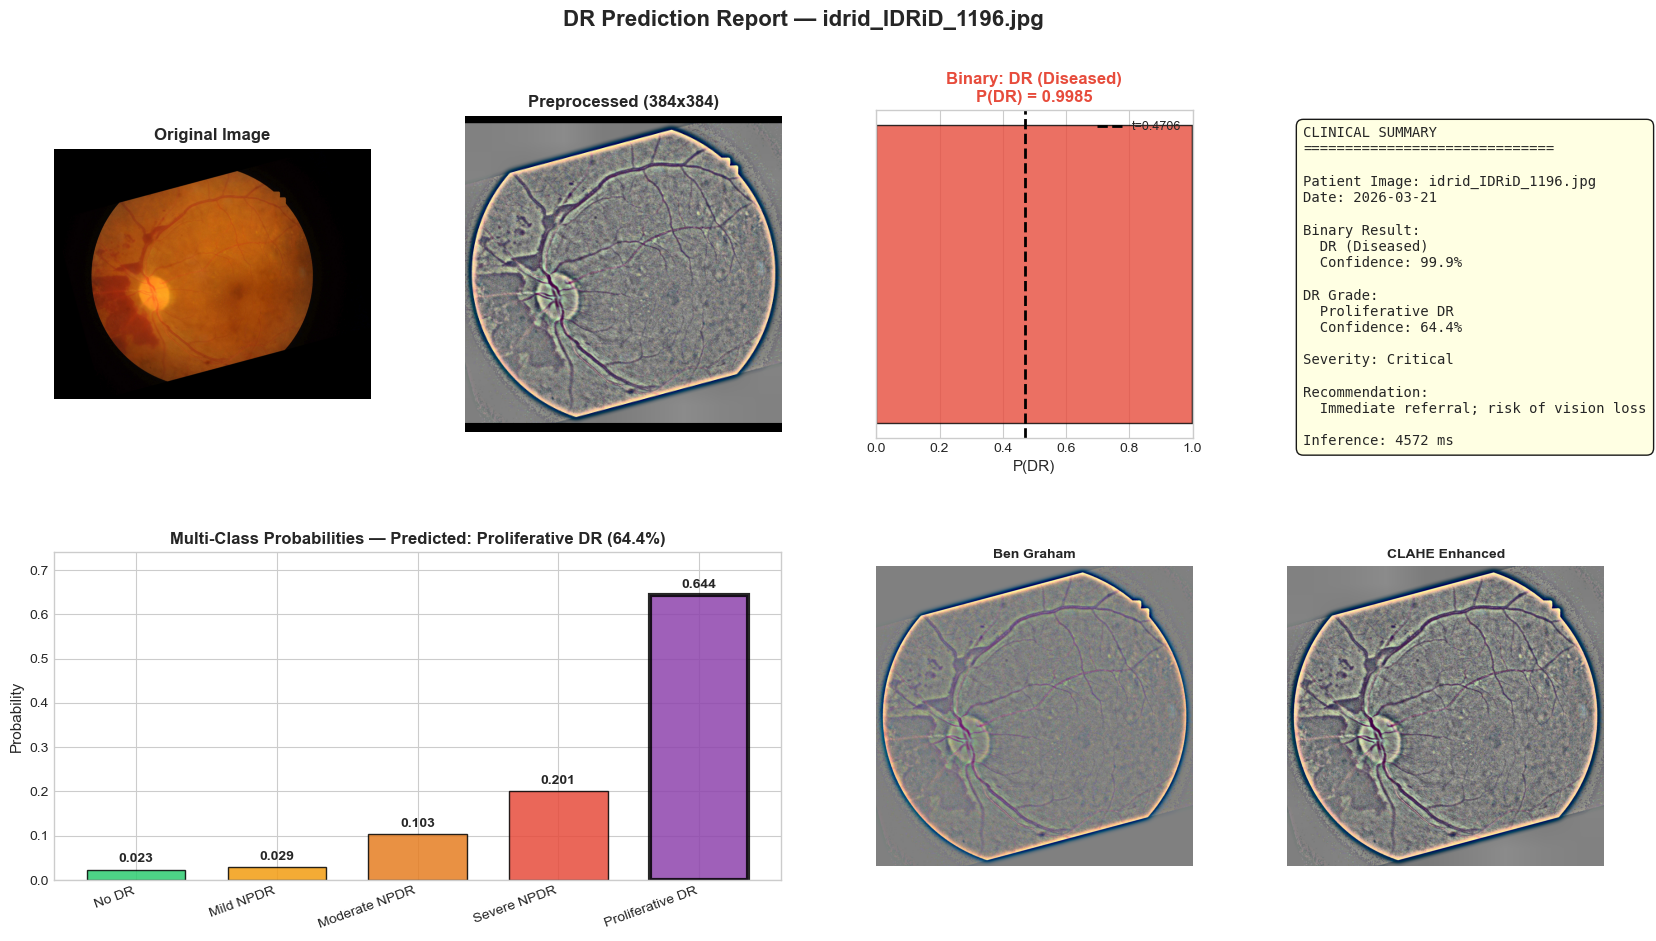


  Report saved: predics/idrid_IDRiD_1196_report.png
  JSON saved:  predics/idrid_IDRiD_1196_result.json

Done!


In [55]:
# ============================================================================
# RUN PREDICTION — Uses IMAGE_PATH, SINGLE_IMAGE, USE_TTA from config
# ============================================================================

os.makedirs(CONFIG['output_dir'], exist_ok=True)
_tta_label = f" (TTA x{TTA_TIMES})" if USE_TTA else ""

if SINGLE_IMAGE:
    # ────────────────────────────────────────────────────────
    #  SINGLE IMAGE MODE
    # ────────────────────────────────────────────────────────
    print("=" * 60)
    print(f"SINGLE IMAGE PREDICTION{_tta_label}")
    print(f"Image: {IMAGE_PATH}")
    print("=" * 60)

    if USE_TTA:
        result = predict_single_image_tta(
            image_path=IMAGE_PATH,
            binary_model=binary_model,
            multiclass_model=multiclass_model,
            threshold=CONFIG['optimal_threshold'],
            n_tta=TTA_TIMES,
            return_preprocessing=True,
        )
    else:
        result = predict_single_image(
            image_path=IMAGE_PATH,
            binary_model=binary_model,
            multiclass_model=multiclass_model,
            threshold=CONFIG['optimal_threshold'],
            return_preprocessing=True,
        )

    print(f"\n  Image:       {result['image_name']}")
    print(f"  Binary:      {result['binary_label']}  (P(DR) = {result['binary_probability']:.4f})")
    if USE_TTA:
        print(f"  Binary STD:  {result.get('binary_prob_std', 0):.4f}  (TTA uncertainty)")
    print(f"  Grade:       {result['multiclass_grade']}  (confidence = {result['multiclass_confidence']:.1%})")
    if USE_TTA:
        print(f"  Grade STD:   {result.get('multiclass_prob_std', 0):.4f}  (TTA uncertainty)")
    print(f"  Severity:    {result['severity']}")
    print(f"  Action:      {result['clinical_action']}")
    print(f"  Time:        {result['inference_time_ms']:.0f} ms")
    if USE_TTA:
        print(f"  TTA views:   {TTA_TIMES}")

    # Visual report
    save_name = f"predics/{Path(IMAGE_PATH).stem}_report.png"
    visualize_prediction(result, save_path=save_name)
    print(f"\n  Report saved: {save_name}")

    # Save JSON result
    json_out = {k: v for k, v in result.items() if not k.startswith('_')}
    json_path = f"predics/{Path(IMAGE_PATH).stem}_result.json"
    with open(json_path, 'w') as f:
        json.dump(json_out, f, indent=2)
    print(f"  JSON saved:  {json_path}")

else:
    # ────────────────────────────────────────────────────────
    #  BATCH MODE
    # ────────────────────────────────────────────────────────
    print("=" * 60)
    print(f"BATCH PREDICTION{_tta_label}")
    print(f"Source: {IMAGE_PATH}")
    print("=" * 60)

    if USE_TTA:
        batch_df = predict_batch_tta(
            image_source=IMAGE_PATH,
            binary_model=binary_model,
            multiclass_model=multiclass_model,
            threshold=CONFIG['optimal_threshold'],
            n_tta=TTA_TIMES,
            output_csv='predics/batch_predictions_tta.csv',
            output_json='predics/batch_predictions_tta.json',
        )
    else:
        batch_df = predict_batch(
            image_source=IMAGE_PATH,
            binary_model=binary_model,
            multiclass_model=multiclass_model,
            threshold=CONFIG['optimal_threshold'],
            batch_size=16,
            output_csv='predics/batch_predictions.csv',
            output_json='predics/batch_predictions.json',
        )

    if len(batch_df) > 0:
        print("\n" + "=" * 100)
        print(f"RESULTS TABLE{_tta_label}")
        print("=" * 100)
        display_cols = ['image_name', 'binary_label', 'binary_probability',
                        'multiclass_grade', 'multiclass_confidence', 'severity']
        print(batch_df[display_cols].to_string(index=False, float_format='{:.4f}'.format))

        print(f"\nSummary:")
        print(f"  Total images:  {len(batch_df)}")
        print(f"  DR detected:   {(batch_df['binary_prediction']==1).sum()} ({(batch_df['binary_prediction']==1).mean()*100:.1f}%)")
        print(f"  No DR:         {(batch_df['binary_prediction']==0).sum()} ({(batch_df['binary_prediction']==0).mean()*100:.1f}%)")
        print(f"\n  Grade distribution:")
        for grade in range(5):
            count = (batch_df['multiclass_prediction']==grade).sum()
            if count > 0:
                print(f"    {GRADE_INFO[grade]['name']:>20s}: {count:4d} ({count/len(batch_df)*100:5.1f}%)")

print("\nDone!")

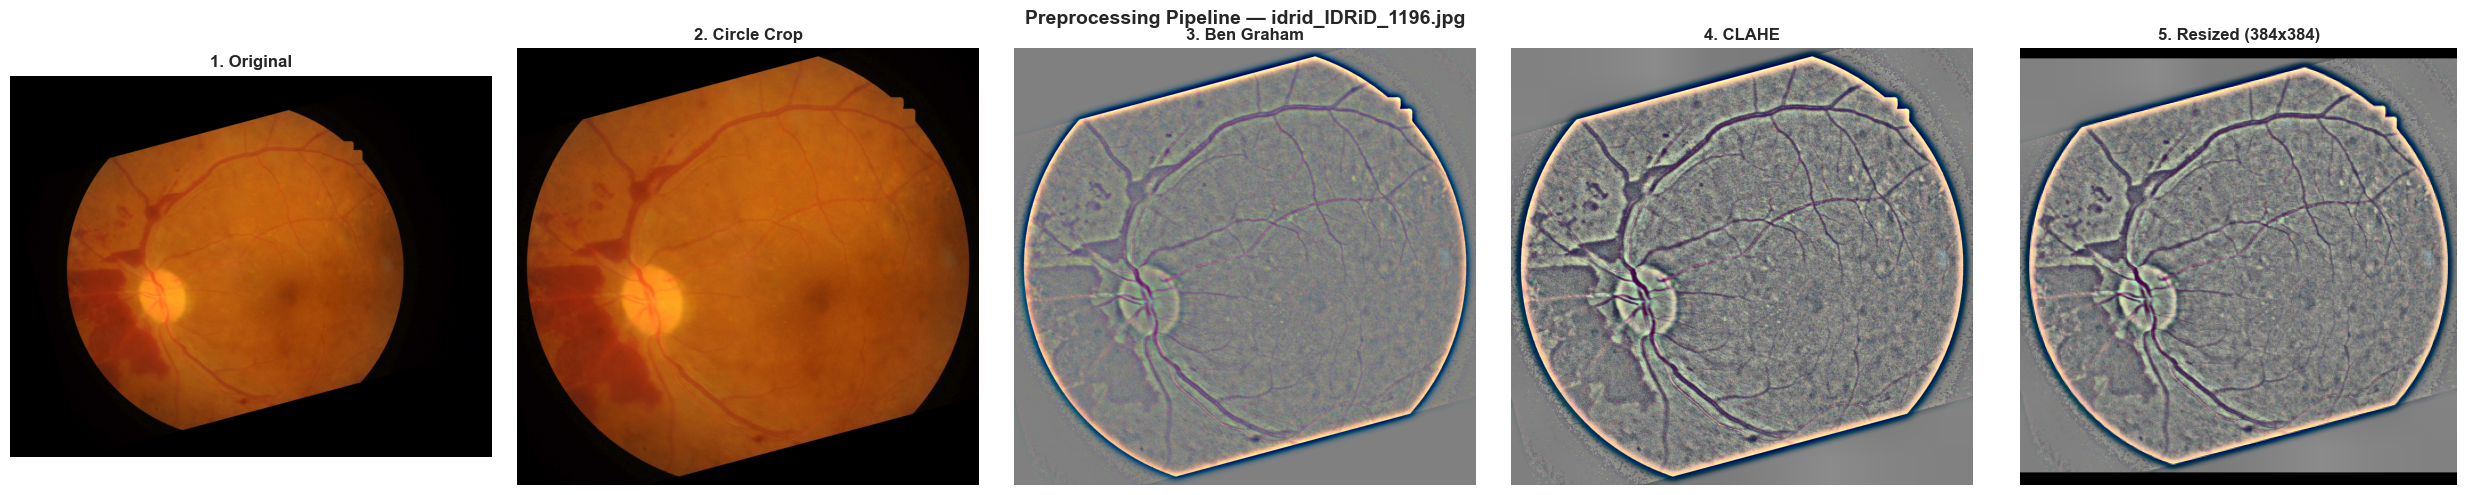

Preprocessing visualization saved


In [56]:
# ============================================================================
# 8. Visualization — Preprocessing Steps (single) or Batch Charts
# ============================================================================

if SINGLE_IMAGE:
    # Show preprocessing pipeline steps for the predicted image
    if '_preprocessing_steps' in result:
        fig, axes = plt.subplots(1, 5, figsize=(25, 5))
        step_titles = ['1. Original', '2. Circle Crop', '3. Ben Graham', '4. CLAHE', '5. Resized (384x384)']
        for ax, (key, img_bgr), title in zip(axes, result['_preprocessing_steps'].items(), step_titles):
            ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
            ax.set_title(title, fontweight='bold', fontsize=12)
            ax.axis('off')
        plt.suptitle(f'Preprocessing Pipeline — {result["image_name"]}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'predics/{Path(IMAGE_PATH).stem}_preprocessing.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Preprocessing visualization saved")

else:
    # Batch results charts
    if len(batch_df) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Batch Prediction Results', fontsize=16, fontweight='bold')

        # Grade Distribution
        grade_counts = batch_df['multiclass_prediction'].value_counts().sort_index()
        colors = [GRADE_INFO[g]['color'] for g in grade_counts.index]
        axes[0, 0].bar(grade_counts.index, grade_counts.values, color=colors, edgecolor='black', alpha=0.85)
        axes[0, 0].set_xticks(range(5))
        axes[0, 0].set_xticklabels([GRADE_INFO[i]['name'] for i in range(5)], rotation=30, ha='right')
        axes[0, 0].set_ylabel('Count')
        axes[0, 0].set_title('Predicted Grade Distribution', fontweight='bold')
        for i, v in enumerate(grade_counts.values):
            axes[0, 0].text(grade_counts.index[i], v + 0.5, str(v), ha='center', fontweight='bold')

        # Binary Probability Distribution
        axes[0, 1].hist(batch_df['binary_probability'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
        axes[0, 1].axvline(x=CONFIG['optimal_threshold'], color='red', linestyle='--', linewidth=2,
                           label=f't={CONFIG["optimal_threshold"]}')
        axes[0, 1].set_xlabel('P(DR)')
        axes[0, 1].set_ylabel('Count')
        axes[0, 1].set_title('Binary Probability Distribution', fontweight='bold')
        axes[0, 1].legend()

        # Confidence by Grade
        grade_groups = batch_df.groupby('multiclass_prediction')['multiclass_confidence']
        conf_data = [group.values for _, group in grade_groups]
        conf_labels = [GRADE_INFO[g]['name'] for g, _ in grade_groups]
        bp = axes[1, 0].boxplot(conf_data, labels=conf_labels, patch_artist=True, notch=True)
        for patch, g in zip(bp['boxes'], [g for g, _ in grade_groups]):
            patch.set_facecolor(GRADE_INFO[g]['color'])
            patch.set_alpha(0.6)
        axes[1, 0].set_ylabel('Confidence')
        axes[1, 0].set_title('Prediction Confidence by Grade', fontweight='bold')
        axes[1, 0].tick_params(axis='x', rotation=30)

        # Severity Pie
        severity_counts = batch_df['severity'].value_counts()
        sev_colors = {'Normal': '#2ecc71', 'Low': '#f39c12', 'Moderate': '#e67e22',
                      'High': '#e74c3c', 'Critical': '#8e44ad'}
        pie_colors = [sev_colors.get(s, '#95a5a6') for s in severity_counts.index]
        axes[1, 1].pie(severity_counts.values, labels=severity_counts.index,
                       colors=pie_colors, autopct='%1.1f%%', startangle=90)
        axes[1, 1].set_title('Severity Distribution', fontweight='bold')

        plt.tight_layout()
        plt.savefig('predics/batch_visualization.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Batch visualization saved")

## Summary

### Quick Reference

| Variable | Purpose | Example |
|----------|---------|---------|
| `IMAGE_PATH` | Path to image or folder | `'IDRiD/Test/images/IDRiD_0001.jpg'` or `'IDRiD/Test/images'` |
| `SINGLE_IMAGE` | `True` = one image, `False` = batch | `True` |
| `USE_TTA` | `True` = enable TTA, `False` = single pass | `True` |
| `TTA_TIMES` | Number of augmented views (1–8) | `8` |

### Test-Time Augmentation (TTA)
Matches Notebook_06 strategy — 8 deterministic views applied after preprocessing:

| View | Augmentation |
|------|-------------|
| 0 | Original (no augmentation) |
| 1 | Horizontal flip |
| 2 | Vertical flip |
| 3 | H+V flip (180° rotation) |
| 4 | Rotate 90° CW |
| 5 | Rotate 90° CW + H flip |
| 6 | Rotate 270° CW |
| 7 | Rotate 270° CW + H flip |

All 8 sigmoid/softmax probabilities are **averaged** for the final prediction.
TTA also reports `binary_prob_std` and `multiclass_prob_std` as uncertainty estimates.

### Preprocessing Pipeline (Identical to Training)
All functions copied **exactly** from `Notebook_01_Preprocessing_Pipeline.ipynb`:

| Step | Function | Formula / Method |
|------|----------|-----------------|
| 1 | `circle_crop(img, tol=10)` | Grayscale threshold → morphological close → bounding rect + 2% margin |
| 2 | `ben_graham_preprocess(img, sigma=30)` | `cv2.addWeighted(img, 4, blur, -4, 128)` |
| 3 | `apply_clahe(img, clip=2.0, grid=(8,8))` | BGR→LAB, CLAHE on L channel, LAB→BGR |
| 4 | `resize_with_padding(img, 384)` | INTER_AREA (↓) / INTER_CUBIC (↑) + `copyMakeBorder` |
| 5 | Normalize | ImageNet `mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]` |

### Model Details
- **Binary:** EfficientNet-B3 → `Dropout(0.4) → Linear(1536, 1)` → sigmoid
- **Multi-class:** EfficientNet-B3 → `Dropout(0.4) → Linear(1536, 5)` → softmax